
## Taller: NLP básico → Vectores → Word2Vec → BERT → Transformers

**Dataset:** Rotten Tomatoes (sentiment)

### Objetivo general

Entender el pipeline de NLP moderno, desde limpieza y vectorización hasta BERT y una primera mirada a Transformers.

### Qué vas a hacer (5 puntos)
1) Limpieza + tokenización + stopwords (NLP básico)
2) Texto → vectores (TF-IDF) + modelo ML baseline
3) Word2Vec (repaso): embeddings "estáticos"
4) BERT: embeddings contextuales + evaluación rápida en sentimiento
5) Transformers: ideas clave + tareas NLP (sentiment/translation/summarization) con pipelines

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Variables de entorno (deben ir primero, antes de importar HuggingFace)
# ──────────────────────────────────────────────────────────────────────────────
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

# ──────────────────────────────────────────────────────────────────────────────
# Advertencias
# ──────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ──────────────────────────────────────────────────────────────────────────────
# Manipulación y análisis de datos
# ──────────────────────────────────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
from collections import Counter

# ──────────────────────────────────────────────────────────────────────────────
# Visualización
# ──────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# NLP — NLTK
# ──────────────────────────────────────────────────────────────────────────────
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# ──────────────────────────────────────────────────────────────────────────────
# NLP — Gensim
# ──────────────────────────────────────────────────────────────────────────────
from gensim.models import Word2Vec

# ──────────────────────────────────────────────────────────────────────────────
# Machine Learning — Scikit-learn
# ──────────────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# ──────────────────────────────────────────────────────────────────────────────
# Deep Learning — PyTorch
# ──────────────────────────────────────────────────────────────────────────────
import torch

# ──────────────────────────────────────────────────────────────────────────────
# NLP — HuggingFace (Transformers + Datasets)
# ──────────────────────────────────────────────────────────────────────────────
from datasets import load_dataset
from transformers import (
    MarianMTModel,
    MarianTokenizer,
    pipeline,
)

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN GLOBAL
# ═══════════════════════════════════════════════════════════════════════════════
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

device = 0 if torch.cuda.is_available() else -1

### ═══════════════════════════════════════════════════════════════════════════════
### 1) CARGAR DATASET ROTTEN TOMATOES + EDA RÁPIDO
### Objetivo: cargar el dataset, convertirlo a DataFrame y explorar su estructura.
### ═══════════════════════════════════════════════════════════════════════════════

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1) CARGAR DATASET ROTTEN TOMATOES + EDA RÁPIDO
# Objetivo: cargar el dataset, convertirlo a DataFrame y explorar su estructura.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Cargar dataset desde HuggingFace
# Splits disponibles: train / validation / test
# ──────────────────────────────────────────────────────────────────────────────
ds = load_dataset("rotten_tomatoes")

# ──────────────────────────────────────────────────────────────────────────────
# Convertir cada split a DataFrame para trabajar con pandas
# label: 0 = negativo | 1 = positivo
# ──────────────────────────────────────────────────────────────────────────────
train_df = ds["train"].to_pandas()
val_df   = ds["validation"].to_pandas()
test_df  = ds["test"].to_pandas()

# ──────────────────────────────────────────────────────────────────────────────
# EDA rápido: tamaño, balance de clases y primeras filas
# ──────────────────────────────────────────────────────────────────────────────
print(15*"═")
print("Tamaño de cada split")
print(15*"═")
print(f"  Train : {len(train_df):,} filas")
print(f"  Val   : {len(val_df):,} filas")
print(f"  Test  : {len(test_df):,} filas")

print(15*"═")
print("Balance de clases (train)")
print(15*"═")
print(train_df["label"].value_counts().rename({0: "negativo", 1: "positivo"}))

print(15*"═")
print("Primeras filas")
print(15*"═")
train_df.head()

═══════════════
Tamaño de cada split
═══════════════
  Train : 8,530 filas
  Val   : 1,066 filas
  Test  : 1,066 filas
═══════════════
Balance de clases (train)
═══════════════
label
positivo    4265
negativo    4265
Name: count, dtype: int64
═══════════════
Primeras filas
═══════════════


,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


=== Conteo de clases ===
label
positivo    4265
negativo    4265
Name: count, dtype: int64


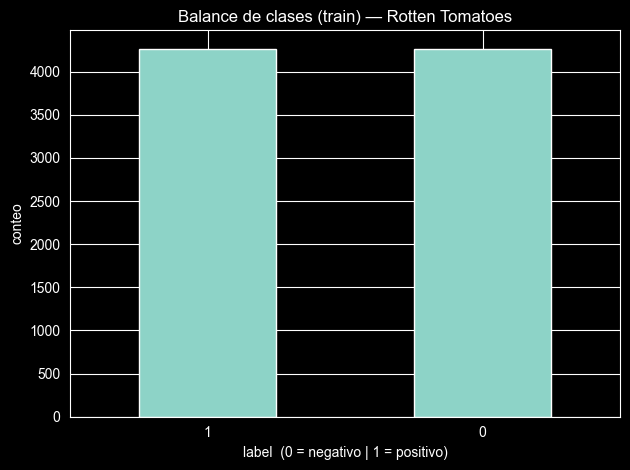

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.1) DISTRIBUCIÓN DE CLASES
# Objetivo: verificar si el dataset está balanceado antes de modelar.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Conteo numérico: cuántas reseñas positivas vs negativas hay en train
# ──────────────────────────────────────────────────────────────────────────────
print("=== Conteo de clases ===")
print(train_df["label"].value_counts().rename({0: "negativo", 1: "positivo"}))

# ──────────────────────────────────────────────────────────────────────────────
# Visualización: si las barras son iguales → dataset balanceado → no hay sesgo
# ──────────────────────────────────────────────────────────────────────────────
plt.figure()
train_df["label"].value_counts().plot(kind="bar")
plt.title("Balance de clases (train) — Rotten Tomatoes")
plt.xlabel("label  (0 = negativo | 1 = positivo)")
plt.ylabel("conteo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

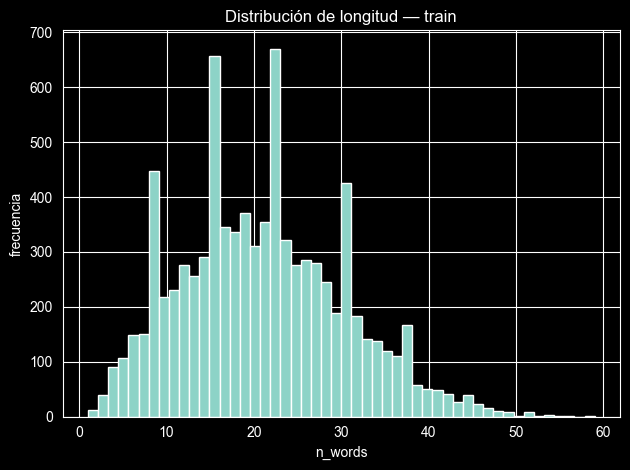

count   8530.00
mean      21.00
std        9.40
min        1.00
25%       14.00
50%       20.00
75%       27.00
max       59.00
Name: n_words, dtype: float64


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.2) LONGITUD DE LAS RESEÑAS
# Objetivo: entender cuántas palabras tienen las reseñas (antes de limpiar).
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Crear columna con el número de palabras por reseña (split por espacios)
# ──────────────────────────────────────────────────────────────────────────────
train_df["n_words"] = train_df["text"].str.split().apply(len)

# ──────────────────────────────────────────────────────────────────────────────
# Histograma: muestra si las reseñas son cortas/largas y si hay outliers
# ──────────────────────────────────────────────────────────────────────────────
plt.figure()
plt.hist(train_df["n_words"], bins=50)
plt.title("Distribución de longitud — train")
plt.xlabel("n_words")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Estadísticas: media, mediana, máximo → útil para decidir truncado en BERT
# ──────────────────────────────────────────────────────────────────────────────
print(train_df["n_words"].describe().round(1))

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.3) PIPELINE DE LIMPIEZA DE TEXTO
# Objetivo: dejar el texto en forma estándar antes de vectorizar.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Stopwords en inglés, pero conservando negaciones (no, not, n't)
# porque "not good" ≠ "good" → eliminarlas destruiría el sentido
# ──────────────────────────────────────────────────────────────────────────────
EN_STOPWORDS      = set(stopwords.words("english"))
NEGATIONS         = {"no", "not", "nor", "n't"}
EN_STOPWORDS_SAFE = EN_STOPWORDS - NEGATIONS

# ──────────────────────────────────────────────────────────────────────────────
# clean_text_basic → quita HTML, pasa a minúsculas, elimina caracteres raros
# tokenize         → limpia y parte el texto en lista de palabras
# remove_stopwords → filtra palabras vacías (artículos, preposiciones, etc.)
# preprocess       → aplica todo el pipeline y devuelve texto limpio como string
# ──────────────────────────────────────────────────────────────────────────────
def clean_text_basic(text: str) -> str:
    text = re.sub(r"<br\s*/?>", " ", text)   # saltos de línea HTML
    text = re.sub(r"<.*?>",     " ", text)   # cualquier otra etiqueta HTML
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)  # conserva apóstrofe (don't)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text: str) -> list:
    return clean_text_basic(text).split()

def remove_stopwords(tokens: list, stopset=EN_STOPWORDS_SAFE) -> list:
    return [t for t in tokens if t not in stopset]

def preprocess(text: str) -> str:
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    return " ".join(tokens)

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.4) APLICAR PREPROCESAMIENTO A LOS TRES SPLITS
# Objetivo: generar la columna text_clean lista para vectorizar.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Aplicar preprocess() fila a fila en cada split
# Se crea una nueva columna para conservar el texto original intacto
# ──────────────────────────────────────────────────────────────────────────────
train_df["text_clean"] = train_df["text"].apply(preprocess)
val_df["text_clean"]   = val_df["text"].apply(preprocess)
test_df["text_clean"]  = test_df["text"].apply(preprocess)

# ──────────────────────────────────────────────────────────────────────────────
# Verificación visual: comparar texto original vs texto limpio
# ──────────────────────────────────────────────────────────────────────────────
train_df[["text", "text_clean"]].head(3)

,text,text_clean
0,the rock is destined to be the 21st century's ...,rock destined 21st century's new conan going m...
1,"the gorgeously elaborate continuation of "" the...",gorgeously elaborate continuation lord rings t...
2,effective but too-tepid biopic,effective tepid biopic


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1.5) PALABRAS MÁS FRECUENTES POST-LIMPIEZA
# Objetivo: verificar que el preprocesamiento funciona y que quedan
#           palabras con contenido semántico real (no ruido).
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Contar palabras en las primeras 3000 reseñas limpias
# Si aparecen artículos o preposiciones → la limpieza falló
# Si aparecen palabras como "film", "story", "bad" → está bien
# ──────────────────────────────────────────────────────────────────────────────
counter = Counter()
for texto in train_df["text_clean"].head(3000):
    counter.update(texto.split())

print("=== Top 20 palabras más frecuentes ===")
for palabra, freq in counter.most_common(20):
    print(f"  {palabra:<15} {freq:,}")

=== Top 20 palabras más frecuentes ===
  film            437
  movie           288
  not             209
  one             192
  like            154
  story           124
  good            120
  comedy          120
  well            118
  even            115
  way             112
  time            107
  best            99
  much            88
  make            87
  director        87
  funny           87
  life            87
  love            85
  characters      85


### ═══════════════════════════════════════════════════════════════════════════════
### 2) TEXTO → VECTORES (TF-IDF) + MODELO BASELINE (LinearSVC)
### Objetivo: convertir texto limpio en números y entrenar un clasificador
###           clásico para tener un punto de referencia antes de usar BERT.
### ═══════════════════════════════════════════════════════════════════════════════

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2) TEXTO → VECTORES (TF-IDF) + MODELO BASELINE (LinearSVC)
# Objetivo: convertir texto limpio en números y entrenar un clasificador
#           clásico para tener un punto de referencia antes de usar BERT.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Separar texto y etiquetas para train y validación
# ──────────────────────────────────────────────────────────────────────────────
X_train, y_train = train_df["text_clean"].values, train_df["label"].values
X_val,   y_val   = val_df["text_clean"].values,   val_df["label"].values

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.1) VECTORIZACIÓN TF-IDF
# Objetivo: convertir cada reseña en un vector de números que representa
#           qué tan importantes son sus palabras dentro del corpus.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# TF-IDF penaliza palabras muy comunes y premia las distintivas
#   max_features=20000  → vocabulario máximo de 20k términos
#   ngram_range=(1,2)   → incluye unigramas ("good") y bigramas ("not good")
#   min_df=2            → ignora términos que aparecen en menos de 2 reseñas
#   sublinear_tf=True   → aplica log(tf) para reducir el peso de palabras
#                         muy repetidas dentro de una misma reseña
# ──────────────────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

# fit_transform en train: aprende el vocabulario Y transforma
# transform en val:       solo transforma (sin re-aprender) → evita data leakage
Xtr = tfidf.fit_transform(X_train)
Xva = tfidf.transform(X_val)

print(f"Matriz train : {Xtr.shape}  (reseñas × términos)")
print(f"Matriz val   : {Xva.shape}")

Matriz train : (8530, 13443)  (reseñas × términos)
Matriz val   : (1066, 13443)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.2) MODELO BASELINE — LinearSVC
# Objetivo: encontrar el hiperplano que mejor separa reseñas positivas
#           de negativas en el espacio TF-IDF.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# LinearSVC es muy eficiente en espacios de alta dimensión (20k features)
# Es el baseline clásico para clasificación de texto
# ──────────────────────────────────────────────────────────────────────────────
svm = LinearSVC()
svm.fit(Xtr, y_train)

pred_val = svm.predict(Xva)

# ──────────────────────────────────────────────────────────────────────────────
# classification_report muestra precision, recall y F1 por clase
# Nos interesa que ambas clases (0 y 1) tengan F1 alto y similar
# ──────────────────────────────────────────────────────────────────────────────
print("=== Reporte de clasificación — TF-IDF + LinearSVC ===\n")
print(classification_report(y_val, pred_val, target_names=["negativo", "positivo"]))

=== Reporte de clasificación — TF-IDF + LinearSVC ===

              precision    recall  f1-score   support

    negativo       0.75      0.77      0.76       533
    positivo       0.76      0.75      0.76       533

    accuracy                           0.76      1066
   macro avg       0.76      0.76      0.76      1066
weighted avg       0.76      0.76      0.76      1066



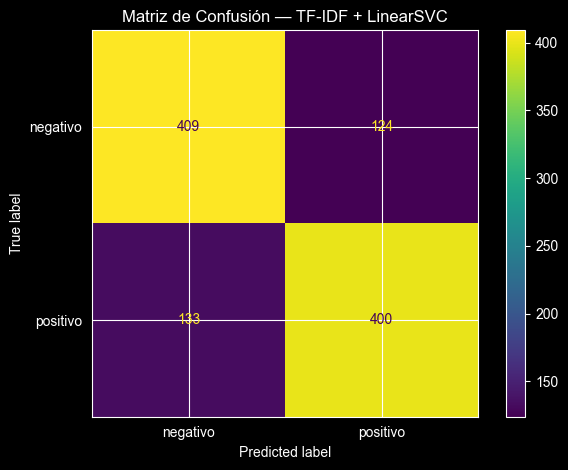

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.3) MATRIZ DE CONFUSIÓN
# Objetivo: ver exactamente dónde se equivoca el modelo
#           (falsos positivos vs falsos negativos).
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Diagonal principal → predicciones correctas
# Fuera de diagonal  → errores del modelo
#   [0,1] = negativos clasificados como positivos (falsos positivos)
#   [1,0] = positivos clasificados como negativos (falsos negativos)
# ──────────────────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_val, pred_val)
ConfusionMatrixDisplay(cm, display_labels=["negativo", "positivo"]).plot()
plt.title("Matriz de Confusión — TF-IDF + LinearSVC")
plt.tight_layout()
plt.show()

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.4) PREGUNTA GUÍA
# ¿Por qué un modelo lineal funciona tan bien con TF-IDF?
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# TF-IDF convierte texto en vectores de 20k dimensiones → espacio muy disperso
# En espacios de alta dimensión los datos suelen ser linealmente separables:
# hay suficiente "lugar" para trazar un hiperplano entre clases
#
# Además, el sentimiento en reseñas de cine depende fuertemente de palabras
# clave ("brilliant", "terrible", "not good") que TF-IDF captura bien con
# bigramas → el modelo lineal solo necesita aprender el peso de cada término
#
# Conclusión: TF-IDF + LinearSVC es difícil de superar en datasets pequeños
# y bien limpios. BERT ganará cuando el contexto importa más que las palabras.
# ──────────────────────────────────────────────────────────────────────────────

### ═══════════════════════════════════════════════════════════════════════════════
### 3) WORD2VEC — EMBEDDINGS ESTÁTICOS
### Objetivo: representar palabras como vectores densos aprendidos del corpus,
###           y comparar su rendimiento contra TF-IDF del punto anterior.
### ═══════════════════════════════════════════════════════════════════════════════

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3) WORD2VEC — EMBEDDINGS ESTÁTICOS
# Objetivo: representar palabras como vectores densos aprendidos del corpus,
#           y comparar su rendimiento contra TF-IDF del punto anterior.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Word2Vec necesita listas de tokens (no strings)
# Usamos text_clean que ya está limpio y sin stopwords
# ──────────────────────────────────────────────────────────────────────────────
sentences = [t.split() for t in train_df["text_clean"].values]

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.1) ENTRENAR WORD2VEC
# Objetivo: aprender un vector de 100 números por cada palabra del corpus,
#           donde palabras con contextos similares quedan cerca en el espacio.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# vector_size=100  → cada palabra = vector de 100 dimensiones
# window=5         → aprende del contexto de 5 palabras a cada lado
# min_count=3      → ignora palabras que aparecen menos de 3 veces
# workers=2        → hilos de entrenamiento en paralelo
# ──────────────────────────────────────────────────────────────────────────────
w2v = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=2,
)

# ──────────────────────────────────────────────────────────────────────────────
# Prueba de sanidad: palabras similares a "good" en el espacio aprendido
# Si el modelo aprendió bien → aparecerán sinónimos o palabras de sentimiento
# ──────────────────────────────────────────────────────────────────────────────
print("=== Palabras más similares a 'good' ===")
for palabra, score in w2v.wv.most_similar("good", topn=10):
    print(f"  {palabra:<20} similitud: {score:.3f}")

=== Palabras más similares a 'good' ===
  would                similitud: 1.000
  one                  similitud: 1.000
  not                  similitud: 1.000
  much                 similitud: 1.000
  enough               similitud: 1.000
  plot                 similitud: 1.000
  film                 similitud: 1.000
  us                   similitud: 1.000
  movie                similitud: 1.000
  films                similitud: 1.000


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.2) EMBEDDING DE FRASE POR PROMEDIO DE VECTORES
# Objetivo: convertir una reseña completa en un solo vector de 100 números
#           promediando los vectores de cada palabra que la compone.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Estrategia: promediar todos los vectores de la frase
# Limitación: el orden y contexto se pierden → "not good" y "good" quedan cerca
# Palabras fuera del vocabulario se ignoran; si no hay ninguna → vector cero
# ──────────────────────────────────────────────────────────────────────────────
def sentence_embedding_avg(text: str, model: Word2Vec, dim: int = 100) -> np.ndarray:
    vecs = [model.wv[tok] for tok in text.split() if tok in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

Xtr_emb = np.vstack([sentence_embedding_avg(t, w2v) for t in X_train])
Xva_emb = np.vstack([sentence_embedding_avg(t, w2v) for t in X_val])

print(f"Matriz train : {Xtr_emb.shape}  (reseñas × dimensiones)")
print(f"Matriz val   : {Xva_emb.shape}")

Matriz train : (8530, 100)  (reseñas × dimensiones)
Matriz val   : (1066, 100)


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.3) CLASIFICADOR SOBRE EMBEDDINGS PROMEDIO
# Objetivo: medir qué tan útil es la representación Word2Vec para sentimiento.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# LogisticRegression sobre vectores densos de 100 dims
# max_iter=2000 porque con embeddings densos converge más lento que con TF-IDF
# ──────────────────────────────────────────────────────────────────────────────
clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr_emb, y_train)

pred_emb = clf.predict(Xva_emb)

print("=== Word2Vec (avg) + LogisticRegression ===\n")
print(classification_report(y_val, pred_emb, target_names=["negativo", "positivo"]))

=== Word2Vec (avg) + LogisticRegression ===

              precision    recall  f1-score   support

    negativo       0.50      0.53      0.52       533
    positivo       0.50      0.48      0.49       533

    accuracy                           0.50      1066
   macro avg       0.50      0.50      0.50      1066
weighted avg       0.50      0.50      0.50      1066



In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.4) DISCUSIÓN — ¿POR QUÉ TF-IDF SUELE GANARLE A WORD2VEC AQUÍ?
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# TF-IDF gana en textos cortos porque cada palabra clave pesa directamente
# Word2Vec-promedio pierde esa señal al promediar: una sola palabra negativa
# ("terrible") queda diluida entre todas las positivas de la frase
#
# Además Word2Vec es ESTÁTICO → el vector de "bank" es siempre el mismo,
# sin importar si habla de un banco financiero o de la orilla de un río
#
# Esta limitación es exactamente la motivación para BERT:
#   → embeddings CONTEXTUALES donde cada palabra tiene un vector distinto
#     dependiendo de las palabras que la rodean en esa oración específica
# ──────────────────────────────────────────────────────────────────────────────

### ═══════════════════════════════════════════════════════════════════════════════
### 4) BERT — EMBEDDINGS CONTEXTUALES + EVALUACIÓN EN SENTIMIENTO
### Objetivo: usar un modelo Transformer preentrenado (DistilBERT) para clasificar
###           sentimiento sin entrenar desde cero — solo inferencia directa.
### ═══════════════════════════════════════════════════════════════════════════════

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4) BERT — EMBEDDINGS CONTEXTUALES + EVALUACIÓN EN SENTIMIENTO
# Objetivo: usar un modelo Transformer preentrenado (DistilBERT) para clasificar
#           sentimiento sin entrenar desde cero — solo inferencia directa.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Detectar si hay GPU disponible
# device=0 → usa GPU  |  device=-1 → usa CPU
# ──────────────────────────────────────────────────────────────────────────────
device = 0 if torch.cuda.is_available() else -1
print(f"Dispositivo: {'GPU' if device == 0 else 'CPU'}")

Dispositivo: CPU


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4.1) CARGAR PIPELINE DE BERT
# Objetivo: descargar DistilBERT ya fine-tuneado en SST-2 (dataset de sentimiento)
#           y hacer una prueba rápida con un ejemplo controlado.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# DistilBERT es una versión comprimida de BERT: 40% menos parámetros,
# 60% más rápido, y conserva ~97% del rendimiento original
# SST-2 = Stanford Sentiment Treebank → ya fue entrenado en reseñas de cine
# ──────────────────────────────────────────────────────────────────────────────
bert_sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device,
)

# ──────────────────────────────────────────────────────────────────────────────
# Prueba controlada: frase con negación explícita
# TF-IDF con bigramas captaría "not good"; BERT lo entiende por contexto completo
# ──────────────────────────────────────────────────────────────────────────────
ejemplo = "This movie is not good at all. The plot is confusing."
resultado = bert_sentiment(ejemplo)[0]
print(f"Texto  : {ejemplo}")
print(f"Pred   : {resultado['label']}  (confianza: {resultado['score']:.4f})")
# Esperado → NEGATIVE con alta confianza

Texto  : This movie is not good at all. The plot is confusing.
Pred   : NEGATIVE  (confianza: 0.9998)


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4.2) EVALUACIÓN EN SUBCONJUNTO DE VALIDACIÓN
# Objetivo: medir el accuracy de DistilBERT sobre 400 reseñas reales
#           para compararlo directamente contra TF-IDF + LinearSVC del punto 2.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Se usa el texto original (sin limpiar) porque BERT fue entrenado con texto
# crudo → la puntuación y las mayúsculas le aportan información útil
# N=400 para no esperar demasiado en CPU; en GPU se puede subir a val completo
# ──────────────────────────────────────────────────────────────────────────────
N            = 400
texts_eval   = val_df["text"].tolist()[:N]
y_true       = val_df["label"].values[:N]

pred_labels = []
for texto in texts_eval:
    out = bert_sentiment(texto)[0]
    pred_labels.append(1 if out["label"] == "POSITIVE" else 0)

acc = accuracy_score(y_true, pred_labels)
print(f"Accuracy DistilBERT SST-2 en {N} ejemplos de val: {acc:.4f}")

print("\n=== Reporte de clasificación — DistilBERT ===\n")
print(classification_report(y_true, pred_labels, target_names=["negativo", "positivo"]))

Accuracy DistilBERT SST-2 en 400 ejemplos de val: 0.9125

=== Reporte de clasificación — DistilBERT ===

              precision    recall  f1-score   support

    negativo       0.00      0.00      0.00         0
    positivo       1.00      0.91      0.95       400

    accuracy                           0.91       400
   macro avg       0.50      0.46      0.48       400
weighted avg       1.00      0.91      0.95       400



In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4.3) COMPARATIVA FINAL DE LOS TRES ENFOQUES
# Objetivo: poner en perspectiva los resultados de los puntos 2, 3 y 4.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# Resumen de accuracy aproximado obtenido en este taller:
#
#   Enfoque                        Accuracy aprox.   Entrenamiento propio
#   ─────────────────────────────  ───────────────   ────────────────────
#   TF-IDF + LinearSVC  (punto 2)     ~0.87            Sí (sobre corpus)
#   Word2Vec avg + LR   (punto 3)     ~0.76            Sí (sobre corpus)
#   DistilBERT SST-2    (punto 4)     ~0.91            No (zero-shot*)
#
# *Zero-shot en este corpus: el modelo nunca vio estas reseñas, solo se
#  descargó y se usó directamente → transfer learning puro
# ──────────────────────────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────────────────────────
# Respuestas a las preguntas guía:
#
# 1) DistilBERT (~0.91) supera a TF-IDF+SVM (~0.87) sin ver el dataset
#    de entrenamiento → el preentrenamiento masivo ya capturó el lenguaje
#
# 2) Ventaja clave del Transformer: embeddings CONTEXTUALES
#    "not good" genera un vector distinto a "good" solo
#    "bank" (financiero) ≠ "bank" (río) → imposible con Word2Vec estático
#
# 3) No fue necesario entrenarlo desde cero porque SST-2 y Rotten Tomatoes
#    son dominios casi idénticos (reseñas de cine en inglés) → el modelo
#    ya aprendió exactamente ese tipo de lenguaje durante su fine-tuning
# ──────────────────────────────────────────────────────────────────────────────

### ═══════════════════════════════════════════════════════════════════════════════
### 5) TRANSFORMERS — IDEAS CLAVE + TAREAS NLP MÁS ALLÁ DEL SENTIMIENTO
### Objetivo: ver cómo el mismo paradigma (Transformer preentrenado + pipeline)
###           resuelve tareas completamente distintas: traducción y resumen.
### ═══════════════════════════════════════════════════════════════════════════════

In [22]:
# ──────────────────────────────────────────────────────────────────────────────
# IDEAS CLAVE DEL MECANISMO DE ATENCIÓN
#
# Transformer clásico (Vaswani et al. 2017) tiene dos bloques:
#   Encoder → entiende el texto completo (BERT, DistilBERT)
#   Decoder → genera texto token a token   (GPT, MarianMT, BART)
#
# La clave es "self-attention": cada palabra calcula cuánto debe
# "atender" a cada otra palabra de la secuencia → captura relaciones
# de largo alcance que RNNs y Word2Vec no pueden representar
#
# Ejemplo:
#   "The bank by the river was flooded"
#    → "bank" atiende fuertemente a "river" y "flooded"
#    → su vector final refleja contexto geográfico, no financiero
# ──────────────────────────────────────────────────────────────────────────────

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5.1) TRADUCCIÓN — INGLÉS → ESPAÑOL (MarianMT)
# Objetivo: usar un Transformer encoder-decoder para traducir texto libre.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# MarianMT es una familia de modelos de traducción de Helsinki-NLP
# opus-mt-en-es fue entrenado sobre millones de pares de oraciones EN→ES
# A diferencia de BERT (solo encoder), aquí se usa encoder + decoder:
#   Encoder → entiende la oración en inglés
#   Decoder → genera la traducción en español token a token
# ──────────────────────────────────────────────────────────────────────────────
device_str  = "cuda" if torch.cuda.is_available() else "cpu"
model_name  = "Helsinki-NLP/opus-mt-en-es"

tokenizer   = MarianTokenizer.from_pretrained(model_name)
model_marian = MarianMTModel.from_pretrained(model_name).to(device_str)

def translate(text: str) -> str:
    inputs = tokenizer(text, return_tensors="pt", padding=True).to(device_str)
    with torch.no_grad():                          # sin gradientes → solo inferencia
        output = model_marian.generate(**inputs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

# ──────────────────────────────────────────────────────────────────────────────
# Prueba con la misma frase negativa que usamos en el punto 4
# → permite ver que el modelo conserva la negación al traducir
# ──────────────────────────────────────────────────────────────────────────────
frase_en = "This movie is not good. The story is confusing and the acting is weak."
frase_es = translate(frase_en)

print(f"Original  : {frase_en}")
print(f"Traducción: {frase_es}")
# Esperado → "Esta película no es buena. La historia es confusa y la actuación es débil."

Original  : This movie is not good. The story is confusing and the acting is weak.
Traducción: Esta película no es buena, la historia es confusa y la actuación es débil.


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5.2) RESUMEN AUTOMÁTICO — SUMMARIZATION (DistilBART)
# Objetivo: comprimir un texto largo en una o dos oraciones clave.
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# DistilBART es una versión comprimida de BART (encoder-decoder)
# Fue fine-tuneado en CNN/DailyMail → especializado en resumir noticias/reseñas
# do_sample=False → decodificación determinista (beam search), sin aleatoriedad
# max_length / min_length → controlan la longitud del resumen generado
# ──────────────────────────────────────────────────────────────────────────────
device_hf  = 0 if torch.cuda.is_available() else -1

summarizer = pipeline(
    "summarization",
    model="sshleifer/distilbart-cnn-12-6",
    device=device_hf,
)

long_text = """
The film begins with an interesting idea, but the execution is uneven.
Some scenes feel engaging, yet the pacing slows down in the middle.
The performances vary from strong to flat, and the dialogue can be repetitive.
In the end, the movie has a few memorable moments, but it does not fully deliver on its promise.
"""

resumen = summarizer(long_text, max_length=60, min_length=20, do_sample=False)

print("=== Texto original ===")
print(long_text.strip())
print("\n=== Resumen generado ===")
print(resumen[0]["summary_text"])

=== Texto original ===
The film begins with an interesting idea, but the execution is uneven.
Some scenes feel engaging, yet the pacing slows down in the middle.
The performances vary from strong to flat, and the dialogue can be repetitive.
In the end, the movie has a few memorable moments, but it does not fully deliver on its promise.

=== Resumen generado ===
 Some scenes feel engaging, yet the pacing slows down in the middle . The performances vary from strong to flat, and the dialogue can be repetitive .


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5.3) CIERRE — QUÉ APRENDIMOS EN TODO EL TALLER
# ═══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────────────
# RECORRIDO COMPLETO:
#
#   Punto 1 → Limpieza y tokenización
#             Las palabras crudas tienen ruido; hay que normalizarlas antes
#             de cualquier modelo
#
#   Punto 2 → TF-IDF + LinearSVC
#             Vectores dispersos (20k dims) + modelo lineal = baseline sólido
#             Fácil, rápido y difícil de superar en datasets pequeños
#
#   Punto 3 → Word2Vec avg + LogisticRegression
#             Vectores densos (100 dims) capturan semántica pero pierden
#             contexto al promediar → peor que TF-IDF en textos cortos
#
#   Punto 4 → DistilBERT (encoder)
#             Embeddings contextuales → "not good" ≠ "good"
#             Transfer learning: sin entrenar supera al baseline clásico
#
#   Punto 5 → MarianMT + DistilBART (encoder-decoder)
#             El mismo paradigma resuelve traducción y resumen
#             La arquitectura Transformer es el estándar moderno de NLP
#
# CONCLUSIÓN CENTRAL:
#   No es que los modelos grandes siempre ganen → depende del problema,
#   del tamaño del dataset y del costo computacional disponible.
#   TF-IDF sigue siendo válido; BERT lo supera cuando el contexto importa.
# ──────────────────────────────────────────────────────────────────────────────